In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
!pip install pandas bayesian-optimization scikit-learn

In [2]:
import pandas as pd

In [16]:
df = pd.read_csv(r"/content/drive/MyDrive/Oyrenme/TimeSeries/GOOG_history.csv")

In [30]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,26.38,26.49,26.13,26.17,25.94,28951268
1,2015-01-05,26.09,26.14,25.58,25.62,25.40,41196796
2,2015-01-06,25.68,25.74,24.98,25.03,24.81,57998800
3,2015-01-07,25.28,25.29,24.91,24.99,24.77,41301082
4,2015-01-08,24.83,25.11,24.48,25.07,24.85,67071641


In [18]:
len(df)

2766

In [28]:
import logging
import pandas as pd
import numpy as np
from prophet import Prophet
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_absolute_error

In [31]:
df = df[["Date", "Close"]]

In [32]:
df.columns = ["ds", "y"]

In [33]:
df

,ds,y
0,2015-01-02,26.17
1,2015-01-05,25.62
2,2015-01-06,25.03
3,2015-01-07,24.99
4,2015-01-08,25.07
...,...,...
2761,2025-12-24,315.67
2762,2025-12-26,314.96
2763,2025-12-29,314.39
2764,2025-12-30,314.55


In [34]:
df["ds"] = pd.to_datetime(df["ds"])

/tmp/ipykernel_681/1982822988.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ds"] = pd.to_datetime(df["ds"])


In [35]:
df

,ds,y
0,2015-01-02,26.17
1,2015-01-05,25.62
2,2015-01-06,25.03
3,2015-01-07,24.99
4,2015-01-08,25.07
...,...,...
2761,2025-12-24,315.67
2762,2025-12-26,314.96
2763,2025-12-29,314.39
2764,2025-12-30,314.55


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      2766 non-null   datetime64[ns]
 1   y       2766 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 43.3 KB


In [37]:
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

In [39]:
train_df

,ds,y
0,2015-01-02,26.17
1,2015-01-05,25.62
2,2015-01-06,25.03
3,2015-01-07,24.99
4,2015-01-08,25.07
...,...,...
2207,2023-10-10,139.20
2208,2023-10-11,141.70
2209,2023-10-12,140.29
2210,2023-10-13,138.58


In [40]:
def prophet_model(changepoint_prior_scale, seasonality_prior_scale, changepoint_range):
    model = Prophet(
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        changepoint_range=changepoint_range
    )
    model.fit(train_df)
    future = model.make_future_dataframe(periods=len(test_df))
    forecast = model.predict(future)

    y_pred = forecast["yhat"].tail(len(test_df)).values
    y_true = test_df["y"].values
    mae = mean_absolute_error(y_true, y_pred)
    return -mae

pbounds = {
    "changepoint_prior_scale": (0.001, 10),
    "seasonality_prior_scale": (0.01, 10),
    "changepoint_range": (0.8, 0.95)
}

optimizer = BayesianOptimization(
    f=prophet_model,
    pbounds=pbounds,
    random_state=42
)

optimizer.maximize(
    init_points=5,
    n_iter=15
)


|   iter    |  target   | change... | season... | change... |
-------------------------------------------------------------


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


| 1         | -22.06420 | 3.7460266 | 9.5076359 | 0.9097990 |


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


| 2         | -69.26153 | 5.9869861 | 1.5686262 | 0.8233991 |


...

| 17        | -80.76690 | 6.4884723 | 6.1015868 | 0.8021030 |


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


| 18        | -20.99302 | 9.8442270 | 7.3690851 | 0.9026540 |


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


| 19        | -39.02908 | 7.3436296 | 3.4810755 | 0.8678409 |
| 20        | -21.65240 | 9.5934582 | 0.8884461 | 0.9450935 |


In [41]:
best_params = optimizer.max["params"]
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'changepoint_prior_scale': np.float64(7.418898102052044), 'seasonality_prior_scale': np.float64(0.01), 'changepoint_range': np.float64(0.95)}


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


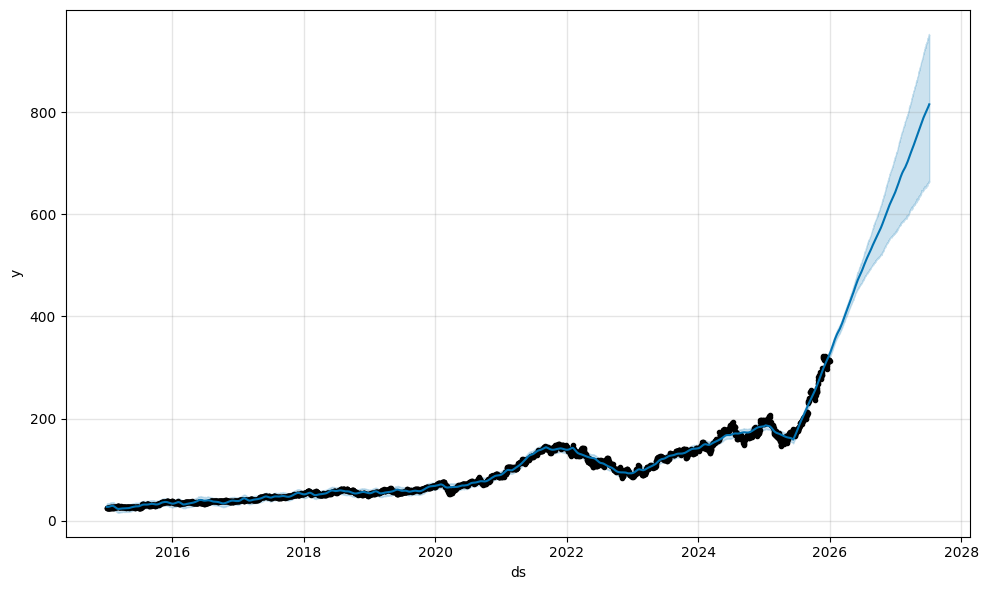

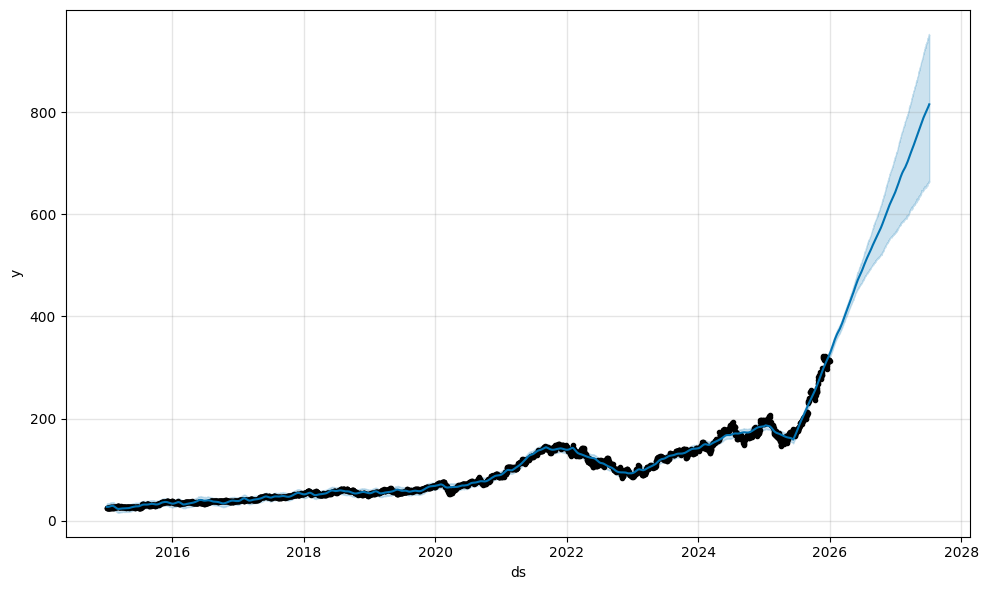

In [44]:
final_model = Prophet(
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    seasonality_prior_scale=best_params["seasonality_prior_scale"],
    changepoint_range=best_params["changepoint_range"]
)

final_model.fit(df)

future = final_model.make_future_dataframe(periods=len(test_df))
forecast = final_model.predict(future)

final_model.plot(forecast)

### Proqnozların qiymətləndirilməsi

Modelin proqnozlarının nə qədər yaxşı olduğunu daha yaxşı başa düşmək üçün, proqnozlaşdırılan dəyərləri faktiki test dəyərləri ilə müqayisə edək.

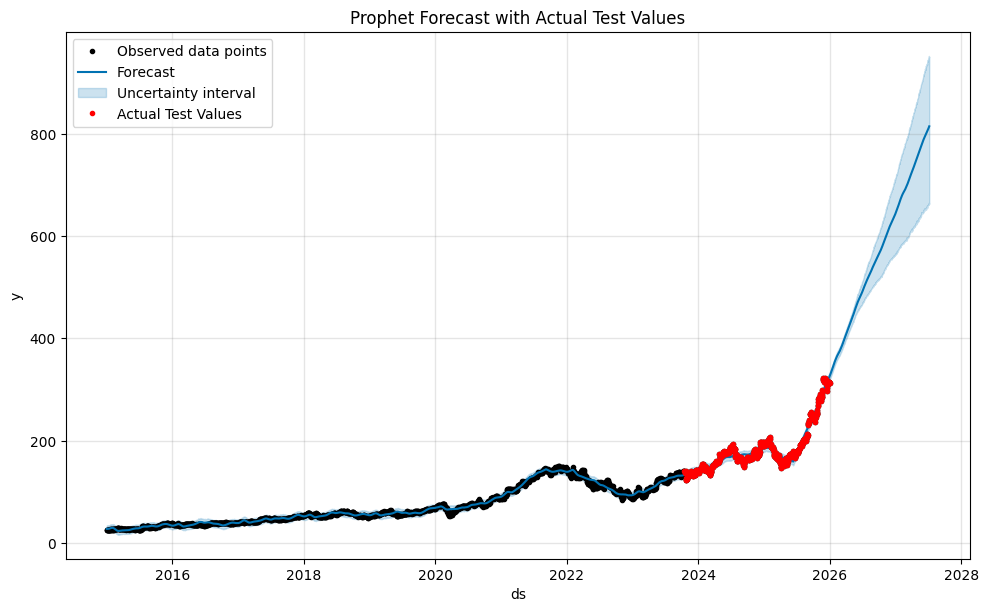

In [45]:
fig2 = final_model.plot(forecast)
ax = fig2.gca()
ax.plot(test_df['ds'], test_df['y'], 'r.', label='Actual Test Values')
ax.legend()
ax.set_title('Prophet Forecast with Actual Test Values')
fig2.show()

Yuxarıdakı qrafikə baxaraq, proqnozların faktiki dəyərləri necə təqib etdiyini vizual olaraq qiymətləndirə bilərik. Qırmızı nöqtələr faktiki test dəyərləridir.

İndi isə modelin performansını ölçmək üçün Ortam Mütləq Səhvi (MAE) hesablayaq:

In [47]:
from sklearn.metrics import mean_absolute_error

# Get the predicted values for the test set from the forecast DataFrame
forecasted_values = forecast[forecast['ds'].isin(test_df['ds'])]['yhat']

# Align actual and forecasted values (important for correct MAE calculation)
# Ensure both are ordered by date and have the same length
y_true = test_df['y'].values
y_pred = forecasted_values.values

mae_final = mean_absolute_error(y_true, y_pred)
print(f"Final Model Mean Absolute Error (MAE) on Test Set: {mae_final:.2f}")

Final Model Mean Absolute Error (MAE) on Test Set: 7.65


MAE dəyəri proqnozlarımızın faktiki dəyərlərdən orta hesabla nə qədər uzaq olduğunu göstərir. Daha kiçik MAE dəyəri daha yaxşı proqnozu göstərir.

Vizual müqayisə və MAE dəyərinə əsasən, modelin proqnozlarının "yaxşı" olub-olmadığı kontekstdən asılıdır. Məsələn, səhmin dəyişkənliyini nəzərə alsaq, bu dəyər qənaətbəxş ola bilər, lakin daha dəqiq proqnozlaşdırmanın tələb olunduğu başqa bir ssenaridə daha aşağı MAE hədəflənə bilər.